# 정합메트릭스
목적: 학습 데이터에서 아키타입-소비 성향 조합이 비정합한 데이터를 탐지/제거\
방법: 통계적 잔차(Chi-square) + 임베딩 응집도 갭(Intra-Inter Similarity)



맨밑 정합 메트릭스 부분이 주요\
나머지는 결과 확인용

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from pathlib import Path
archePath       = Path("/content/drive/MyDrive/data/sampled_nemotron_personas_10k.csv")
cosunmPath       = Path("/content/drive/MyDrive/data/nemotron_cluster_types.csv")

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# 1. 데이터 로드
df_persona = pd.read_csv(archePath)
df_cluster = pd.read_csv(cosunmPath)

# 5X5 빈도수 확인

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/

[ 5x5 아키타입 X 클러스터 데이터 개수 메트릭스 ]
type1        사회적 소비  적극적 소비  자기 중심적  윤리적 소비  소극적 실속
Archetype 0     342    1203      52      70      16
Archetype 1     633     885      39      54      12
Archetype 2     310     542      28      44       8
Archetype 3     627     960      35      67      16
Archetype 4     677    1182      89     133      18
총 조인된 데이터 개수: 8042개



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53412 (\N{HANGUL SYLLABLE KI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/

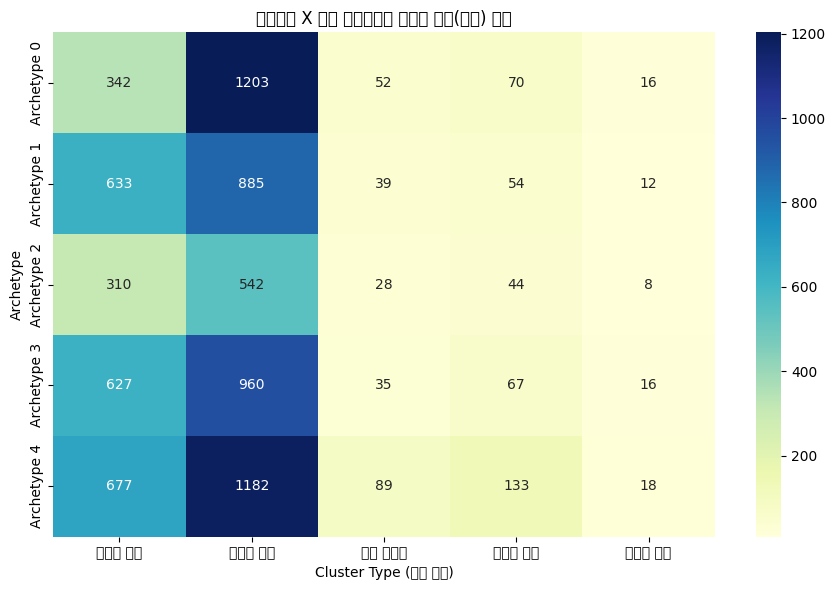

In [ ]:
# 1. 데이터 조인
df_merged = pd.merge(df_persona, df_cluster, on='uuid', how='inner')

# 2. 지정된 5가지 클러스터 타입 순서 정의 (축 정렬용)
cluster_order = ['사회적 소비', '적극적 소비', '자기 중심적', '윤리적 소비', '소극적 실속']

# 3. crosstab을 활용한 5x5 빈도수(개수) 메트릭스 생성
# 행(index)은 archetype, 열(columns)은 소비 성향(type1)
count_matrix = pd.crosstab(
    df_merged['archetype'],
    df_merged['type1']
)

# 열 순서대로 정렬
count_matrix = count_matrix.reindex(columns=cluster_order, fill_value=0)

print("=" * 60)
# 인덱스와 컬럼명 깔끔하게 정리 후 출력
count_matrix.index = [f'Archetype {i}' for i in count_matrix.index]
print("[ 5x5 아키타입 X 클러스터 데이터 개수 메트릭스 ]")
print("=" * 60)
print(count_matrix)
print("=" * 60)
print(f"총 조인된 데이터 개수: {count_matrix.values.sum()}개\n")


# 4. 시각적인 확인을 위한 Heatmap 그리기
plt.rc('font', family='NanumGothic') # 한글 깨짐 방지 (환경에 맞게 폰트 수정 가능)

plt.figure(figsize=(9, 6))
# 갯수 출력이므로 정수 형태(fmt='d')로 지정
sns.heatmap(count_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('아키타입 X 소비 클러스터별 데이터 개수(빈도) 분포')
plt.ylabel('Archetype')
plt.xlabel('Cluster Type (소비 성향)')
plt.tight_layout()
plt.show()

# 5X5 임베딩 유사도 확인

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.86k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

각 그룹별 페르소나 텍스트 임베딩 추출 중...


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/


[5x5 메트릭스 결과: 각 그룹 내부의 페르소나 텍스트 유사도 평균]
             사회적 소비  적극적 소비  자기 중심적  윤리적 소비  소극적 실속
Archetype 0  0.4171  0.4223  0.4126  0.4252  0.4480
Archetype 1  0.4945  0.4837  0.4864  0.4874  0.5201
Archetype 2  0.4585  0.4363  0.4441  0.4405  0.4829
Archetype 3  0.4783  0.4688  0.5092  0.4587  0.4761
Archetype 4  0.4412  0.4327  0.4362  0.4331  0.4421


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54168 (\N{HANGUL SYLLABLE PE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47476 (\N{HANGUL SYLLABLE REU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

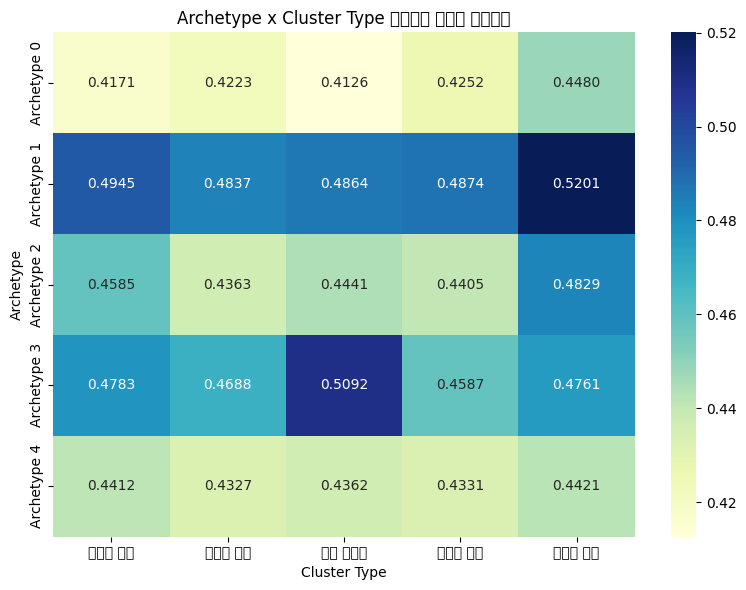

In [ ]:
# uuid 기준으로 조인
df_merged = pd.merge(df_persona, df_cluster, on='uuid', how='inner')

# 분석에 사용할 주요 컬럼 정의 (여기서는 주 소비 성향인 type1을 기준으로 설정)
# archetype: 0, 1, 2, 3, 4 (5가지)
# consum tag: '사회적 소비', '적극적 소비', '자기 중심적', '윤리적 소비', '소극적 실속' (5가지)
archetypes = sorted(df_merged['archetype'].unique())
cluster_types = ['사회적 소비', '적극적 소비', '자기 중심적', '윤리적 소비', '소극적 실속']

# 2. 한국어 임베딩 모델 로드
model = SentenceTransformer('jhgan/ko-sroberta-multitask')

print("각 그룹별 페르소나 텍스트 임베딩 추출 중...")

# 3. 각 그룹(Archetype x Cluster)의 대표 임베딩 계산
# 행: Archetype (5), 열: Cluster (5) 구조의 딕셔너리/리스트 준비
group_embeddings = {}

for arch in archetypes:
    group_embeddings[arch] = {}
    for cluster in cluster_types:
        # 해당 archetype과 cluster 타입에 속하는 데이터 필터링
        filtered_df = df_merged[(df_merged['archetype'] == arch) & (df_merged['type1'] == cluster)]

        if len(filtered_df) > 0:
            # persona 컬럼의 텍스트 추출 및 임베딩 생성
            sentences = filtered_df['persona'].tolist()
            embeddings = model.encode(sentences)
            # 그룹 내 페르소나들의 평균 벡터를 대표 벡터로 사용
            mean_embedding = np.mean(embeddings, axis=0)
            group_embeddings[arch][cluster] = mean_embedding
        else:
            # 만약 해당 조합에 데이터가 없다면 제로 벡터 처리
            group_embeddings[arch][cluster] = np.zeros(model.get_sentence_embedding_dimension())

# 4. 5x5 메트릭스 생성 (예: 행을 Archetype, 열을 Cluster로 설정)
# 여기서는 각 그룹이 '전체 페르소나 공간'에서 얼마나 유사한지 보기 위해
# 기준이 되는 전체 평균 페르소나 벡터 또는 그룹 간 직접 비교를 matrix 형태로 시각화합니다.
# 질문하신 취지에 맞게 [Archetype 수(5) x Cluster 수(5)]의 값 자체를 채우기 위해,
# 각 칸(i, j)에 해당 그룹의 내부 유사도(자기들끼리 얼마나 뭉쳐있는가) 혹은
# 특정 기준 벡터와의 유사도를 넣을 수 있습니다.

# 여기서는 '각 조합(행,열)에 속한 페르소나 집단'의 고유한 특징 벡터를
# 시각적으로 확인하기 위해 데이터프레임으로 구조화합니다.

matrix_data = []
for arch in archetypes:
    row = []
    for cluster in cluster_types:
        # 예시: 해당 그룹 내 페르소나들 간의 평균 코사인 유사도 계산
        filtered_df = df_merged[(df_merged['archetype'] == arch) & (df_merged['type1'] == cluster)]
        if len(filtered_df) > 1:
            sentences = filtered_df['persona'].tolist()
            embeddings = model.encode(sentences)
            sim_matrix = cosine_similarity(embeddings)
            # 자기 자신과의 유사도(1.0)를 제외한 평균 유사도
            mean_sim = (np.sum(sim_matrix) - len(sentences)) / (len(sentences) * (len(sentences) - 1))
            row.append(round(mean_sim, 4))
        elif len(filtered_df) == 1:
            row.append(1.0) # 데이터가 1개인 경우
        else:
            row.append(0.0) # 데이터가 없는 경우
    matrix_data.append(row)

# 5. 결과 DataFrame 변환
similarity_matrix_df = pd.DataFrame(matrix_data, index=[f'Archetype {a}' for a in archetypes], columns=cluster_types)

print("\n[5x5 메트릭스 결과: 각 그룹 내부의 페르소나 텍스트 유사도 평균]")
print(similarity_matrix_df)

# 6. Heatmap 시각화 (선택 사항)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 깨짐 방지 설정 (실행 환경에 맞는 한글 폰트 지정 필요)
plt.rc('font', family='NanumGothic')

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix_df, annot=True, cmap='YlGnBu', fmt='.4f', cbar=True)
plt.title('Archetype x Cluster Type 페르소나 유사도 메트릭스')
plt.ylabel('Archetype')
plt.xlabel('Cluster Type')
plt.tight_layout()
plt.show()

In [ ]:
!pip install pandas konlpy

# 각 타입 별 최빈 키워드 확인

In [ ]:
import pandas as pd
from collections import Counter
from konlpy.tag import Okt

# 1. 데이터 로드 및 조인
df_merged = pd.merge(df_persona, df_cluster, on='uuid', how='inner')

# 2. 분석 대상 정의
archetypes = sorted(df_merged['archetype'].unique())
cluster_types = ['사회적 소비', '적극적 소비', '자기 중심적', '윤리적 소비', '소극적 실속']

# 형태소 분석기 초기화
okt = Okt()

# 분석에 제외할 불용어(의미 없는 단어들) 정의
stopwords = ['씨', '명', '세', '등', '및', '위해', '통해', '자신', '그', '이', '것', '대한', '때문', '상태', '거주', '여성', '남성']

print("--- 아키타입 X 클러스터 조합별 빈출 단어 추출 시작 ---\n")

# 3. 5x5 교차 조합 반복문 수행
for arch in archetypes:
    print(f"=========================================")
    print(f"■ Archetype {arch}")
    print(f"=========================================")

    for cluster in cluster_types:
        # 해당 조건에 맞는 데이터 필터링
        filtered_df = df_merged[(df_merged['archetype'] == arch) & (df_merged['type1'] == cluster)]

        print(f" ➡️ [{cluster}] (데이터 수: {len(filtered_df)}개)")

        if len(filtered_df) == 0:
            print("   - 해당하는 데이터가 없습니다.")
            print("-" * 40)
            continue

        # 모든 페르소나 텍스트 합치기
        all_text = " ".join(filtered_df['persona'].astype(str).tolist())

        # 명사(Noun)만 추출
        nouns = okt.nouns(all_text)

        # 글자 수가 2글자 이상이고 불용어에 포함되지 않는 단어만 필터링
        filtered_nouns = [word for word in nouns if len(word) >= 2 and word not in stopwords]

        # 단어 빈도수 계산 (상위 5개 추출)
        word_counts = Counter(filtered_nouns)
        top_keywords = word_counts.most_common(5)

        # 결과 출력
        if top_keywords:
            keyword_str = ", ".join([f"{word}({count}회)" for word, count in top_keywords])
            print(f"   ★ 상위 키워드: {keyword_str}")
        else:
            print("   - 추출된 유의미한 키워드가 없습니다.")

        print("-" * 40)
    print("\n")

--- 아키타입 X 클러스터 조합별 빈출 단어 추출 시작 ---

■ Archetype 0
 ➡️ [사회적 소비] (데이터 수: 342개)
   ★ 상위 키워드: 가족(85회), 청년(75회), 일상(60회), 안정(56회), 가장(50회)
----------------------------------------
 ➡️ [적극적 소비] (데이터 수: 1203개)
   ★ 상위 키워드: 가족(271회), 청년(269회), 일상(199회), 안정(179회), 동시(177회)
----------------------------------------
 ➡️ [자기 중심적] (데이터 수: 52개)
   ★ 상위 키워드: 청년(20회), 능력(12회), 안정(8회), 일상(8회), 가족(8회)
----------------------------------------
 ➡️ [윤리적 소비] (데이터 수: 70개)
   ★ 상위 키워드: 청년(18회), 안정(17회), 관리(13회), 동시(13회), 취업(13회)
----------------------------------------
 ➡️ [소극적 실속] (데이터 수: 16개)
   ★ 상위 키워드: 청년(7회), 일상(6회), 관리(5회), 준비(4회), 성격(3회)
----------------------------------------


■ Archetype 1
 ➡️ [사회적 소비] (데이터 수: 633개)
   ★ 상위 키워드: 가족(305회), 가장(277회), 이자(138회), 일상(137회), 안정(114회)
----------------------------------------
 ➡️ [적극적 소비] (데이터 수: 885개)
   ★ 상위 키워드: 가족(383회), 가장(341회), 일상(183회), 이자(178회), 안정(127회)
----------------------------------------
 ➡️ [자기 중심적] (데이터 수: 39개)
   ★ 상위 키워드: 가장(18회), 가족(12

In [ ]:
import pandas as pd
from collections import Counter
from konlpy.tag import Okt

# 1. 데이터 로드 및 조인
df_merged = pd.merge(df_persona, df_cluster, on='uuid', how='inner')

# 형태소 분석기 초기화
okt = Okt()

# 분석에서 제외할 기본 불용어 (형식적인 단어들 제거)
stopwords = ['씨', '명', '세', '등', '및', '위해', '통해', '자신', '그', '이', '것', '대한', '때문', '상태', '거주', '여성', '남성']

# 키워드 추출 공통 함수 정의
def extract_top_keywords(text_list, top_n=10):
    all_text = " ".join(text_list.astype(str).tolist())
    nouns = okt.nouns(all_text)
    # 2글자 이상이고 불용어에 없는 단어만 필터링
    filtered_nouns = [word for word in nouns if len(word) >= 2 and word not in stopwords]
    return Counter(filtered_nouns).most_common(top_n)


# =========================================================================
# PART 1. 아키타입(Archetype)별 상위 키워드 출력 (5개 그룹)
# =========================================================================
print("=" * 60)
print(" PART 1. 아키타입(Archetype)별 페르소나 핵심 키워드 (상위 10개)")
print("=" * 60)

archetypes = sorted(df_merged['archetype'].unique())

for arch in archetypes:
    target_df = df_merged[df_merged['archetype'] == arch]
    print(f"■ Archetype {arch} (데이터 수: {len(target_df)}개)")

    if len(target_df) > 0:
        keywords = extract_top_keywords(target_df['persona'], top_n=10)
        keyword_str = ", ".join([f"{word}({count}회)" for word, count in keywords])
        print(f"  📌 주요 단어: {keyword_str}")
    else:
        print("  데이터가 없습니다.")
    print("-" * 60)

print("\n\n")

# =========================================================================
# PART 2. 클러스터 타입(Cluster Type)별 상위 키워드 출력 (5개 그룹)
# =========================================================================
print("=" * 60)
print(" PART 2. 소비 클러스터(Cluster Type)별 페르소나 핵심 키워드 (상위 10개)")
print("=" * 60)

cluster_types = ['사회적 소비', '적극적 소비', '자기 중심적', '윤리적 소비', '소극적 실속']

for cluster in cluster_types:
    target_df = df_merged[df_merged['type1'] == cluster]
    print(f"■ 소비 성향: [{cluster}] (데이터 수: {len(target_df)}개)")

    if len(target_df) > 0:
        keywords = extract_top_keywords(target_df['persona'], top_n=10)
        keyword_str = ", ".join([f"{word}({count}회)" for word, count in keywords])
        print(f"  📌 주요 단어: {keyword_str}")
    else:
        print("  데이터가 없습니다.")
    print("-" * 60)

 PART 1. 아키타입(Archetype)별 페르소나 핵심 키워드 (상위 10개)
■ Archetype 0 (데이터 수: 1683개)
  📌 주요 단어: 청년(389회), 가족(379회), 일상(285회), 안정(263회), 동시(237회), 이자(219회), 관리(218회), 가장(212회), 식도락(209회), 성격(204회)
------------------------------------------------------------
■ Archetype 1 (데이터 수: 1623개)
  📌 주요 단어: 가족(725회), 가장(663회), 일상(342회), 이자(339회), 안정(259회), 관리(233회), 숙련(211회), 책임감(207회), 건강(205회), 베테(190회)
------------------------------------------------------------
■ Archetype 2 (데이터 수: 932개)
  📌 주요 단어: 가족(305회), 일상(182회), 역사(122회), 조리사(121회), 이자(120회), 가장(118회), 동시(108회), 관리(108회), 현실(103회), 안정(102회)
------------------------------------------------------------
■ Archetype 3 (데이터 수: 1705개)
  📌 주요 단어: 가족(506회), 일상(426회), 관리(344회), 건강(295회), 이웃(268회), 성격(254회), 가장(252회), 살림(244회), 주부(222회), 노후(221회)
------------------------------------------------------------
■ Archetype 4 (데이터 수: 2099개)
  📌 주요 단어: 가족(505회), 청년(466회), 균형(403회), 동시(391회), 안정(353회), 관리(333회), 일상(333회), 이자(331회), 사이(308회), 가장(308회)
------------

# 임베딩 갭 확인

In [ ]:
df_merged = pd.merge(df_persona, df_cluster, on='uuid', how='inner')

archetypes = sorted(df_merged['archetype'].unique())
cluster_types = ['사회적 소비', '적극적 소비', '자기 중심적', '윤리적 소비', '소극적 실속']

# 2. 임베딩 모델 로드 및 전체 텍스트 임베딩 사전 계산
model = SentenceTransformer('jhgan/ko-sroberta-multitask')
print("전체 페르소나 문장 벡터 임베딩 변환 중... (시간이 소요될 수 있습니다)")
all_embeddings = model.encode(df_merged['persona'].tolist(), show_progress_bar=True)
df_merged['embedding_idx'] = range(len(df_merged))

print("\n--- 5x5 조합별 수렴성(응집도) 검증 시작 ---")

results = []

# 3. 5x5 교차 조합별로 내부 vs 외부 유사도 계산
for arch in archetypes:
    for cluster in cluster_types:
        # 현재 분석 타겟 그룹 (In-Group)
        target_mask = (df_merged['archetype'] == arch) & (df_merged['type1'] == cluster)
        target_df = df_merged[target_mask]
        n_samples = len(target_df)

        # 데이터 개수가 너무 적으면 통계적 수렴성 계산 불가 (최소 3개 이상 권장)
        if n_samples < 3:
            results.append({
                'Archetype': f'Arch {arch}', 'Cluster': cluster, 'Count': n_samples,
                'Intra_Sim': 0.0, 'Inter_Sim': 0.0, 'Gap': 0.0, 'Status': '🔴 노이즈 (샘플 부족)'
            })
            continue

        # 타겟 그룹의 임베딩 추출
        target_idxs = target_df['embedding_idx'].tolist()
        target_embs = all_embeddings[target_idxs]

        # 비교 대상 외부 그룹의 임베딩 추출 (Out-Group: 같은 아키타입 내 타 클러스터 또는 타 아키타입)
        outside_embs = all_embeddings[~target_mask]

        # ① 그룹 내부 유사도 (Intra-Similarity): 자기들끼리의 코사인 유사도 평균
        intra_sim_matrix = cosine_similarity(target_embs)
        # 자기 자신과의 유사도(대각선 1.0)를 제외한 순수 타인과의 유사도 평균 계산
        intra_sim = (np.sum(intra_sim_matrix) - n_samples) / (n_samples * (n_samples - 1))

        # ② 그룹 간 유사도 (Inter-Similarity): 외부 사람들과의 코사인 유사도 평균
        inter_sim_matrix = cosine_similarity(target_embs, outside_embs)
        inter_sim = np.mean(inter_sim_matrix)

        # ③ 유사도 갭 (Gap): 내부 결속력이 외부와의 간격보다 얼마나 우수한가
        # 한국어 문장 특성상 베이스라인이 높으므로(0.90대), 두 수치의 미세한 차이(Gap)가 유효성을 결정합니다.
        gap = intra_sim - inter_sim

        # ④ 수렴성 기반 상태 판별 보수적 기준 생성
        if gap > 0.005:  # 내부 응집도가 외부보다 명확히 높은 경우
            status = '🟢 유효 (뚜렷한 세그먼트)'
        elif gap >= 0.001: # 비슷하지만 내부 결속이 조금 더 우세한 경우
            status = '🟡 모호 (경계선상의 조합)'
        else: # 외부 데이터와 전혀 구분이 안 되거나 오히려 내부 결속이 떨어지는 경우
            status = '❌ 오류 (허상/분산 조합)'

        results.append({
            'Archetype': f'Arch {arch}',
            'Cluster': cluster,
            'Count': n_samples,
            'Intra_Sim': round(intra_sim, 4),
            'Inter_Sim': round(inter_sim, 4),
            'Gap': round(gap, 4),
            'Status': status
        })

# 4. 판별 결과 리포트 출력
df_report = pd.DataFrame(results)

print("\n" + "="*85)
print("[ 수렴성 검증 및 최종 조합 유효성 판별 리포트 ]")
print("="*85)
print(df_report.to_string(index=False))
print("="*85)

# 5. 요약 통계 출력
print("\n[ 판별 결과 요약 ]")
print(df_report['Status'].value_counts())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


전체 페르소나 문장 벡터 임베딩 변환 중... (시간이 소요될 수 있습니다)


Batches:   0%|          | 0/252 [00:00<?, ?it/s]


--- 5x5 조합별 수렴성(응집도) 검증 시작 ---

[ 수렴성 검증 및 최종 조합 유효성 판별 리포트 ]
Archetype Cluster  Count  Intra_Sim  Inter_Sim     Gap          Status
   Arch 0  사회적 소비    342     0.4171     0.4180 -0.0009 ❌ 오류 (허상/분산 조합)
   Arch 0  적극적 소비   1203     0.4223     0.4156  0.0067 🟢 유효 (뚜렷한 세그먼트)
   Arch 0  자기 중심적     52     0.4126     0.4025  0.0101 🟢 유효 (뚜렷한 세그먼트)
   Arch 0  윤리적 소비     70     0.4252     0.4123  0.0129 🟢 유효 (뚜렷한 세그먼트)
   Arch 0  소극적 실속     16     0.4480     0.4062  0.0418 🟢 유효 (뚜렷한 세그먼트)
   Arch 1  사회적 소비    633     0.4945     0.4410  0.0535 🟢 유효 (뚜렷한 세그먼트)
   Arch 1  적극적 소비    885     0.4837     0.4372  0.0465 🟢 유효 (뚜렷한 세그먼트)
   Arch 1  자기 중심적     39     0.4864     0.4456  0.0408 🟢 유효 (뚜렷한 세그먼트)
   Arch 1  윤리적 소비     54     0.4874     0.4449  0.0425 🟢 유효 (뚜렷한 세그먼트)
   Arch 1  소극적 실속     12     0.5201     0.4548  0.0652 🟢 유효 (뚜렷한 세그먼트)
   Arch 2  사회적 소비    310     0.4585     0.4301  0.0283 🟢 유효 (뚜렷한 세그먼트)
   Arch 2  적극적 소비    542     0.4363     0.4249  0.0113 🟢 유효 (뚜렷한 세그먼트)
   Arch 2  자기 

# 정합메트릭스

1. 표준화 잔차를 통한 통계학적 필터링
2. 임베딩 갭을 통한 의미적 필터링

둘다 걸리면 탈락\
하나만 걸리면 주의\
다 통과하면 통과


In [1]:
!pip uninstall sympy -y
!pip install --upgrade sympy

Found existing installation: sympy 1.14.0
Uninstalling sympy-1.14.0:
  Successfully uninstalled sympy-1.14.0
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)


In [2]:
# 한글 폰트 설치
!apt-get install -y fonts-nanum
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 폰트 등록 및 캐시 업데이트
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (20.1 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [6]:
"""
Nemotron Personas Korea - 아키타입 × 소비 성향 정합성 필터링 파이프라인
==========================================================================
목적: 학습 데이터에서 아키타입-소비 성향 조합이 비정합한 데이터를 탐지/제거
방법: 통계적 잔차(Chi-square) + 임베딩 응집도 갭(Intra-Inter Similarity)
"""

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import sympy
import sympy.printing
from sympy.printing.precedence import PRECEDENCE

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


In [7]:

# ─────────────────────────────────────────────
# 0. 설정
# ─────────────────────────────────────────────
plt.rc('font', family='NanumGothic')

CLUSTER_ORDER = ['사회적 소비', '적극적 소비', '자기 중심적', '윤리적 소비', '소극적 실속']

# 최종 판정 임계값 (조정 가능)
CHI_THRESHOLD    = -1.5   # 표준화 잔차: 이 값 이하면 통계적으로 "비정합" 신호
GAP_THRESHOLD    = 0.012  # 임베딩 갭: 이 값 미만이면 임베딩상 "비정합" 신호
MIN_SAMPLE_COUNT = 3      # 이 개수 미만인 조합은 판정 불가(SKIP)로 처리

✅ 데이터 로드 완료 | 총 7,632개 | 아키타입: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

📊 카이제곱 검정 결과: χ²=269.58, p=0.0000, dof=16

[ 표준화 잔차 매트릭스 ] (< -2.0 이면 비정합 신호 🔴)
type1   사회적 소비  적극적 소비  자기 중심적  윤리적 소비  소극적 실속
Arch 0   -5.51    3.43   -0.23   -3.07    3.67
Arch 1    5.97   -1.32   -2.05   -0.52   -4.02
Arch 2    0.66    1.60   -0.23    0.83   -3.40
Arch 3    4.28    0.08   -1.75   -1.17   -3.71
Arch 4   -4.67   -3.07    3.77    3.73    5.93


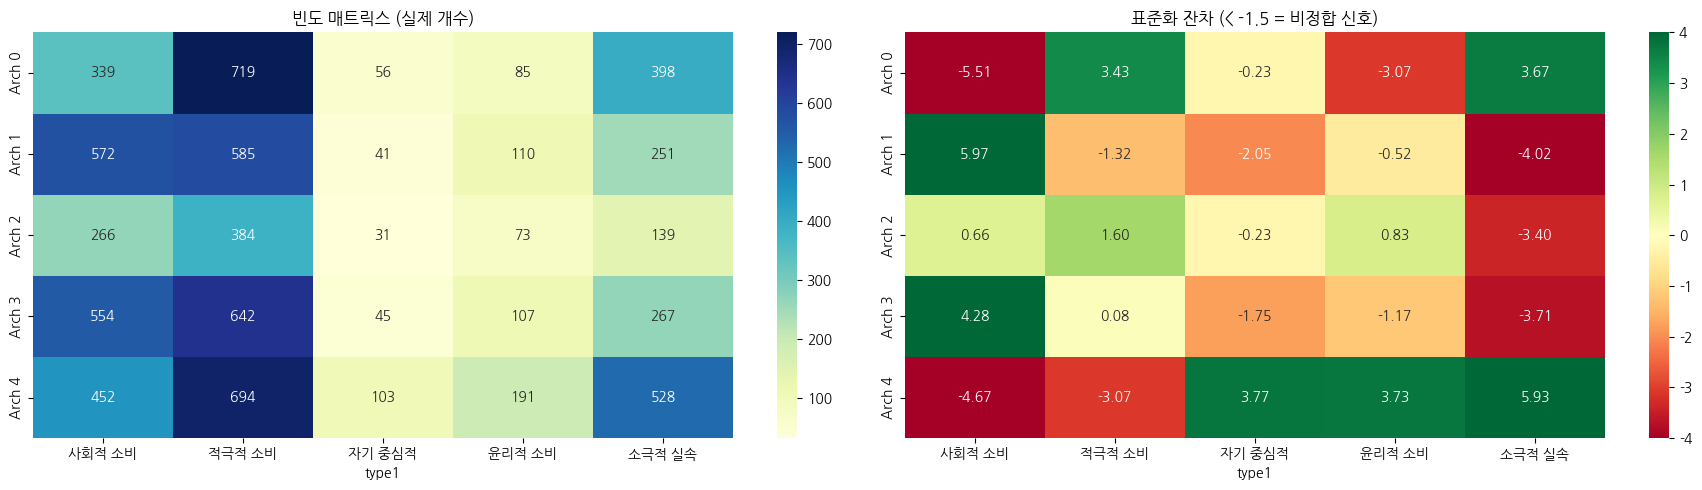

📡 디바이스 설정: cuda | 모델 로드 중 ('BAAI/bge-m3')...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]


🔄 전체 페르소나 임베딩 변환 중 (bge-m3)...


Batches:   0%|          | 0/239 [00:00<?, ?it/s]


[ 임베딩 응집도 갭 결과 ]
Archetype Cluster  Count  Intra_Sim  Inter_Sim  Emb_Gap Emb_Signal
   Arch 0  사회적 소비    339     0.4884     0.4857   0.0027        BAD
   Arch 0  적극적 소비    719     0.4900     0.4850   0.0051        BAD
   Arch 0  자기 중심적     56     0.4937     0.4833   0.0104        BAD
   Arch 0  윤리적 소비     85     0.4949     0.4872   0.0077        BAD
   Arch 0  소극적 실속    398     0.4964     0.4840   0.0124         OK
   Arch 1  사회적 소비    572     0.5052     0.4864   0.0188         OK
   Arch 1  적극적 소비    585     0.5034     0.4878   0.0155         OK
   Arch 1  자기 중심적     41     0.5019     0.4903   0.0115        BAD
   Arch 1  윤리적 소비    110     0.5084     0.4918   0.0166         OK
   Arch 1  소극적 실속    251     0.5091     0.4888   0.0203         OK
   Arch 2  사회적 소비    266     0.5011     0.4889   0.0123         OK
   Arch 2  적극적 소비    384     0.4937     0.4877   0.0060        BAD
   Arch 2  자기 중심적     31     0.5035     0.4901   0.0134         OK
   Arch 2  윤리적 소비     73     0.5095     0.49

In [8]:



# ─────────────────────────────────────────────
# STEP 1. 데이터 로드 및 조인
# ─────────────────────────────────────────────
from pathlib import Path

archePath  = Path("/content/drive/MyDrive/data/sampled_nemotron_personas_10k.csv")
clusterPath = Path("/content/drive/MyDrive/data/nemotron_cluster_types.csv")

df_persona = pd.read_csv(archePath)
df_cluster = pd.read_csv(clusterPath)
df = pd.merge(df_persona, df_cluster, on='uuid', how='inner')

archetypes = sorted(df['archetype'].unique())
print(f"✅ 데이터 로드 완료 | 총 {len(df):,}개 | 아키타입: {archetypes}")


# ─────────────────────────────────────────────
# STEP 2. 5×5 빈도 매트릭스 & 카이제곱 표준화 잔차
# ─────────────────────────────────────────────
count_matrix = pd.crosstab(df['archetype'], df['type1'])
count_matrix = count_matrix.reindex(columns=CLUSTER_ORDER, fill_value=0)
count_matrix.index = [f'Arch {i}' for i in count_matrix.index]

chi2, p, dof, expected = chi2_contingency(count_matrix)
expected_df = pd.DataFrame(expected, index=count_matrix.index, columns=count_matrix.columns)

# 표준화 잔차: (관측-기대) / sqrt(기대)
residual_df = (count_matrix - expected_df) / np.sqrt(expected_df)

print(f"\n📊 카이제곱 검정 결과: χ²={chi2:.2f}, p={p:.4f}, dof={dof}")
print("\n[ 표준화 잔차 매트릭스 ] (< -2.0 이면 비정합 신호 🔴)")
print(residual_df.round(2).to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.heatmap(count_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('빈도 매트릭스 (실제 개수)')

sns.heatmap(residual_df, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-4, vmax=4, ax=axes[1])
axes[1].set_title('표준화 잔차 (< -1.5 = 비정합 신호)')

plt.tight_layout()
plt.savefig('step2_chi_residual.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────
# STEP 3. 임베딩 기반 응집도 갭 계산 (BGE-m3 반영)
# ─────────────────────────────────────────────
import torch

# 1. BAAI/bge-m3 모델 로드 (GPU 가속 확인)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"📡 디바이스 설정: {device} | 모델 로드 중 ('BAAI/bge-m3')...")

model = SentenceTransformer('BAAI/bge-m3', device=device)

print("\n🔄 전체 페르소나 임베딩 변환 중 (bge-m3)...")
# bge-m3는 무거우므로 안전하게 batch_size를 지정하고, 정규화(normalize_embeddings)를 적용합니다.
all_embeddings = model.encode(
    df['persona'].tolist(),
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True  # 코사인 유사도 계산 속도 및 정확도 향상
)
df['emb_idx'] = range(len(df))

embedding_results = []

for arch in archetypes:
    for cluster in CLUSTER_ORDER:
        mask = (df['archetype'] == arch) & (df['type1'] == cluster)
        target_df = df[mask]
        n = len(target_df)

        row_base = {
            'Archetype': f'Arch {arch}',
            'Cluster': cluster,
            'Count': n,
        }

        if n < MIN_SAMPLE_COUNT:
            embedding_results.append({**row_base,
                'Intra_Sim': None, 'Inter_Sim': None, 'Emb_Gap': None,
                'Emb_Signal': 'SKIP'})
            continue

        t_embs = all_embeddings[target_df['emb_idx'].tolist()]
        o_embs = all_embeddings[~mask]

        # 내적 유사도 (Intra Similarity)
        intra_mat = cosine_similarity(t_embs)
        intra_sim = (np.sum(intra_mat) - n) / (n * (n - 1))

        # 외적 유사도 (Inter Similarity)
        inter_sim = np.mean(cosine_similarity(t_embs, o_embs))
        gap = intra_sim - inter_sim

        emb_signal = 'BAD' if gap < GAP_THRESHOLD else 'OK'

        embedding_results.append({**row_base,
            'Intra_Sim': round(intra_sim, 4),
            'Inter_Sim': round(inter_sim, 4),
            'Emb_Gap':   round(gap, 4),
            'Emb_Signal': emb_signal})

emb_df = pd.DataFrame(embedding_results)
print("\n[ 임베딩 응집도 갭 결과 ]")
print(emb_df.to_string(index=False))



[ 최종 정합성 판별 리포트 ]
Archetype Cluster  Count  Chi_Residual  Emb_Gap Final_Verdict
   Arch 0  사회적 소비    339     -5.511409   0.0027     ❌ INVALID
   Arch 0  적극적 소비    719      3.427805   0.0051      🟡 REVIEW
   Arch 0  자기 중심적     56     -0.230691   0.0104      🟡 REVIEW
   Arch 0  윤리적 소비     85     -3.072346   0.0077     ❌ INVALID
   Arch 0  소극적 실속    398      3.667915   0.0124       🟢 VALID
   Arch 1  사회적 소비    572      5.970345   0.0188       🟢 VALID
   Arch 1  적극적 소비    585     -1.316371   0.0155       🟢 VALID
   Arch 1  자기 중심적     41     -2.048178   0.0115     ❌ INVALID
   Arch 1  윤리적 소비    110     -0.522449   0.0166       🟢 VALID
   Arch 1  소극적 실속    251     -4.024063   0.0203      🟡 REVIEW
   Arch 2  사회적 소비    266      0.661552   0.0123       🟢 VALID
   Arch 2  적극적 소비    384      1.603892   0.0060      🟡 REVIEW
   Arch 2  자기 중심적     31     -0.227710   0.0134       🟢 VALID
   Arch 2  윤리적 소비     73      0.832378   0.0174       🟢 VALID
   Arch 2  소극적 실속    139     -3.396311   0.0093    

/tmp/ipykernel_4165/1216819915.py:77: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_4165/1216819915.py:77: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_4165/1216819915.py:77: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_4165/1216819915.py:78: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  plt.savefig('step5_final_verdict_heatmap.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_4165/1216819915.py:78: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) NanumGothic.
  plt.savefig('step5_final_verdict_heatmap.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_4165/1216819915.py:78: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) NanumGothic.
  plt.savefig('step5_final_verdict_heatmap.png', dpi=150,

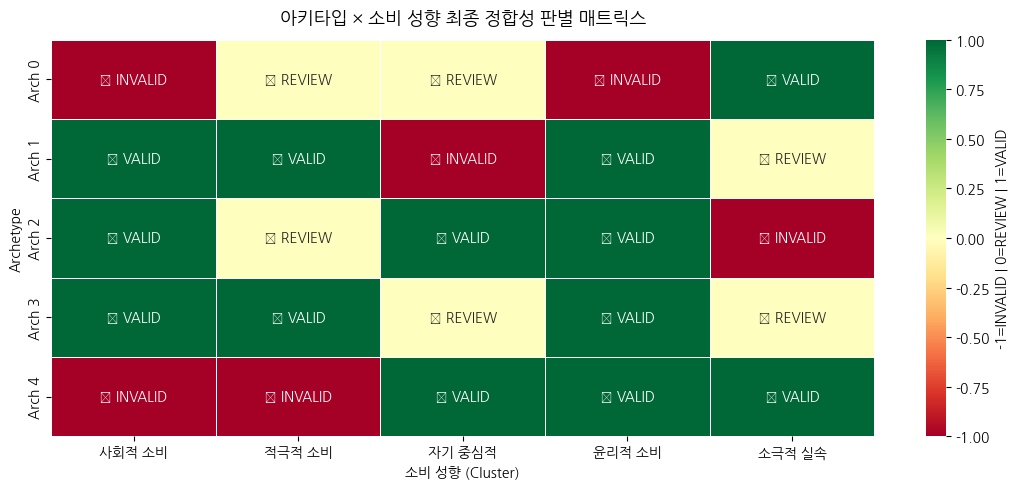

In [9]:

# ─────────────────────────────────────────────
# STEP 4. 두 신호 종합 → 최종 판정
# ─────────────────────────────────────────────

# 1. reset_index() 후 기본 생성되는 'index' 컬럼을 'Archetype'으로 바로 변경하며 melt 진행
residual_long = residual_df.reset_index().melt(
    id_vars='index',              # reset_index() 하면 기본 컬럼명은 'index'가 됩니다
    var_name='Cluster',
    value_name='Chi_Residual'
)

# 2. 'index' 컬럼 이름을 다른 데이터와 병합할 수 있도록 'Archetype'으로 변경
residual_long.rename(columns={'index': 'Archetype'}, inplace=True)

# 결합 (이후 코드는 동일)
combined = emb_df.merge(residual_long, on=['Archetype', 'Cluster'], how='left')

def judge(row):
    """
    두 신호를 종합한 최종 판정 로직

    INVALID : 두 신호 모두 비정합 → 학습 데이터에서 제거 권장
    REVIEW  : 한 신호만 비정합   → 수동 검토 또는 가중치 감소
    VALID   : 두 신호 모두 정합  → 그대로 사용
    SKIP    : 샘플 부족          → 판정 보류
    """
    if row['Emb_Signal'] == 'SKIP':
        return 'SKIP'

    chi_bad = (row['Chi_Residual'] is not None) and (row['Chi_Residual'] < CHI_THRESHOLD)
    emb_bad = (row['Emb_Gap'] is not None) and (row['Emb_Gap'] < GAP_THRESHOLD)
    if chi_bad and emb_bad:
        return '❌ INVALID'
    elif chi_bad or emb_bad:
        return '🟡 REVIEW'
    else:
        return '🟢 VALID'

combined['Final_Verdict'] = combined.apply(judge, axis=1)

print("\n" + "=" * 90)
print("[ 최종 정합성 판별 리포트 ]")
print("=" * 90)
cols_show = ['Archetype', 'Cluster', 'Count', 'Chi_Residual', 'Emb_Gap', 'Final_Verdict']
print(combined[cols_show].to_string(index=False))
print("=" * 90)
print("\n[ 판정 요약 ]")
print(combined['Final_Verdict'].value_counts())


# ─────────────────────────────────────────────
# STEP 5. 최종 판결 매트릭스 히트맵 시각화
# ─────────────────────────────────────────────

verdict_map = {'🟢 VALID': 1, '🟡 REVIEW': 0, '❌ INVALID': -1, 'SKIP': np.nan}
combined['Verdict_Score'] = combined['Final_Verdict'].map(verdict_map)

verdict_pivot = combined.pivot(index='Archetype', columns='Cluster', values='Verdict_Score')
verdict_pivot = verdict_pivot[CLUSTER_ORDER]  # 열 순서 고정

# 레이블용 판정 텍스트 피벗
label_pivot = combined.pivot(index='Archetype', columns='Cluster', values='Final_Verdict')
label_pivot = label_pivot[CLUSTER_ORDER]

plt.figure(figsize=(11, 5))
sns.heatmap(verdict_pivot,
            annot=label_pivot,
            fmt='',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            cbar_kws={'label': '-1=INVALID | 0=REVIEW | 1=VALID'})
plt.title('아키타입 × 소비 성향 최종 정합성 판별 매트릭스', fontsize=13, pad=12)
plt.ylabel('Archetype')
plt.xlabel('소비 성향 (Cluster)')
plt.tight_layout()
plt.savefig('step5_final_verdict_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()



/tmp/ipykernel_4165/4081724688.py:36: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_4165/4081724688.py:36: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_4165/4081724688.py:36: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) NanumGothic.
  plt.tight_layout()
/tmp/ipykernel_4165/4081724688.py:39: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) NanumGothic.
  plt.savefig('step5_final_verdict_heatmap.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_4165/4081724688.py:39: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) NanumGothic.
  plt.savefig('step5_final_verdict_heatmap.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_4165/4081724688.py:39: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) NanumGothic.
  plt.savefig('step5_final_verdict_heatmap.png', dpi=300,

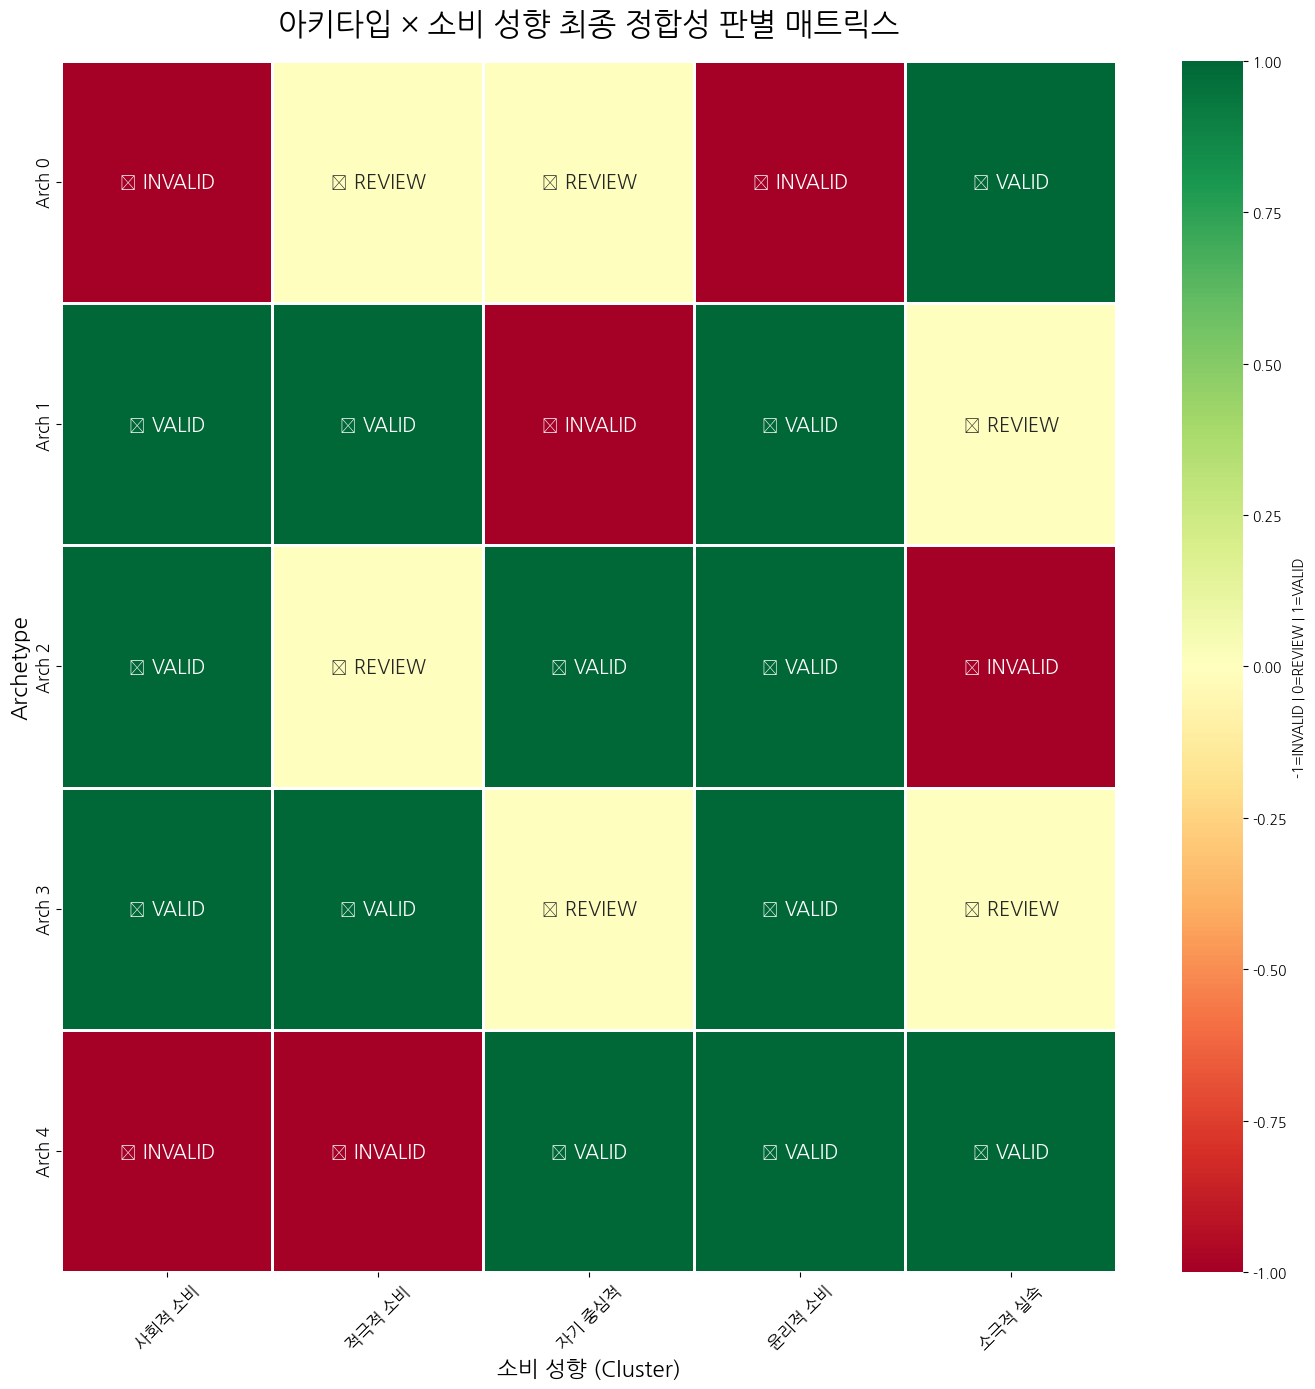

In [10]:
# ─────────────────────────────────────────────
# STEP 5. 최종 판결 매트릭스 히트맵 시각화 (고해상도 수정 버전)
# ─────────────────────────────────────────────

verdict_map = {'🟢 VALID': 1, '🟡 REVIEW': 0, '❌ INVALID': -1, 'SKIP': np.nan}
combined['Verdict_Score'] = combined['Final_Verdict'].map(verdict_map)

verdict_pivot = combined.pivot(index='Archetype', columns='Cluster', values='Verdict_Score')
verdict_pivot = verdict_pivot[CLUSTER_ORDER]  # 열 순서 고정

# 레이블용 판정 텍스트 피벗
label_pivot = combined.pivot(index='Archetype', columns='Cluster', values='Final_Verdict')
label_pivot = label_pivot[CLUSTER_ORDER]

# 1. figsize를 14x14로 늘려 정사각형에 가까운 고해상도 캔버스를 만듭니다.
plt.figure(figsize=(14, 14))

# 2. 고해상도에 맞춰 글자 크기(annot_kws)와 선 두께(linewidths)를 키워줍니다.
sns.heatmap(verdict_pivot,
            annot=label_pivot,
            fmt='',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=2.0,  # 그리드 선 두께를 조금 더 두껍게 조절
            annot_kws={'size': 14, 'weight': 'bold'},  # 히트맵 내부 글자 크기 확대
            cbar_kws={'label': '-1=INVALID | 0=REVIEW | 1=VALID'})

# 3. 전체적인 라벨 및 타이틀 폰트 크기 조절
plt.title('아키타입 × 소비 성향 최종 정합성 판별 매트릭스', fontsize=22, pad=20, weight='bold')
plt.ylabel('Archetype', fontsize=16)
plt.xlabel('소비 성향 (Cluster)', fontsize=16)
plt.xticks(fontsize=12, rotation=45)  # 필요 시 X축 라벨 회전 및 크기 조절
plt.yticks(fontsize=12)

plt.tight_layout()

# 4. dpi=300으로 설정하여 (14인치 * 300 = 4200픽셀) 고해상도로 저장합니다.
plt.savefig('step5_final_verdict_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

임베딩 갭의 밀도 분포 시각화\
빨간 선보다 밑에가 임계값을 넘지 못한 케이스

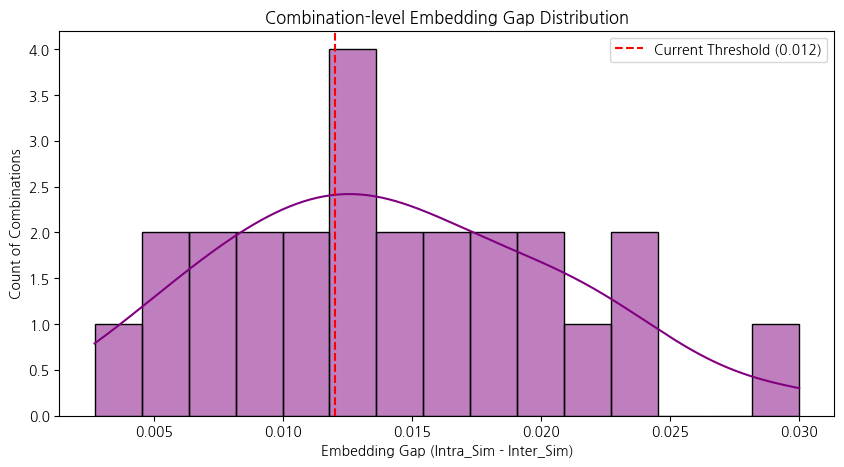

In [11]:
plt.figure(figsize=(10, 5))
# 전체 조합의 Emb_Gap 분산 플롯 (SKIP 제외)
valid_gaps = combined[combined['Emb_Signal'] != 'SKIP']['Emb_Gap']

sns.histplot(valid_gaps, bins=15, kde=True, color='purple')
plt.axvline(x=GAP_THRESHOLD, color='red', linestyle='--', label=f'Current Threshold ({GAP_THRESHOLD})')
plt.title('Combination-level Embedding Gap Distribution')
plt.xlabel('Embedding Gap (Intra_Sim - Inter_Sim)')
plt.ylabel('Count of Combinations')
plt.legend()
plt.show()